In [69]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams["font.size"] = 15

from tqdm import tqdm

from scipy.fft import fft, fftfreq

import sys
sys.path.append('../../')
from tracker import loadAntData, pltsaveall, discretizeTrajectoryIndices

# Update source files before running each cell
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
dataFile = '/home/jack/Workspaces/data/ant_tracking/ant_dataset_1_2026-02-01.h5'

minimumLength = 10 # seconds
smoothingWindow = 10 # frames
maximumTimeSkip = 10 # frames

excludeOutliers = True
excludeShortSegments = True
excludeObjects = True

padding = None # mm
inversePadding = None # mm

dataArr, timeArr, metadataArr = loadAntData(dataFile, minimumLength=minimumLength,
                                            smoothingWindow=smoothingWindow, maximumTimeSkip=maximumTimeSkip,
                                            excludeOutliers=excludeOutliers, excludeShortSegments=excludeShortSegments,
                                            excludeObjects=excludeObjects,
                                            borderPadding=padding, inverseBorderPadding=inversePadding,
                                            debug=True)

Loading SLEAP data: 100%|██████████████████| 1434/1434 [00:02<00:00, 615.22it/s]


Loaded 387 segments!


In [3]:
c = np.arccos(45 / 180 * np.pi)
velocityThreshold = 5 # mm/s
minDistancePerRun = 1 # mm
minStepsPerRun = 5 # frames

signalArr = []
tArr = []

for i in tqdm(range(len(dataArr))):
    dt = 1/metadataArr[i]["fps"]
    runIntervals, waitIntervals = discretizeTrajectoryIndices(dataArr[i],
                                                          c=c,
                                                          velocityThreshold=velocityThreshold,
                                                          dt=dt,
                                                          minSteps=minStepsPerRun,
                                                          minDistancePerRun=minDistancePerRun,
                                                          debug=False)

    if len(runIntervals) == 0 or len(waitIntervals) == 0:
        signalArr.append(np.zeros(0))
        tArr.append(np.zeros(0))
        continue
        
    signal = np.zeros(max(np.max(runIntervals[:,1]), np.max(waitIntervals[:,1])), dtype=bool)

    for j in range(len(runIntervals)):
        signal[runIntervals[j][0]:runIntervals[j][1]] = True

    signalArr.append(signal)
    tArr.append(np.arange(len(signal)) * dt)

  9%|███▉                                      | 36/387 [00:50<06:14,  1.07s/it]/home/jack/Workspaces/python/tracker/notebooks/uncleaned/../../tracker/discretize.py:123: RuntimeWarning: invalid value encountered in divide
  absoluteAngleArr = np.arctan2(*(originalStepDirectionArr.T / np.sqrt(np.sum(originalStepDirectionArr**2, axis=-1))))
100%|█████████████████████████████████████████| 387/387 [01:50<00:00,  3.50it/s]


In [7]:
signalArr = [s for s in signalArr if len(s)]
tArr = [t for t in signalArr if len(t)]

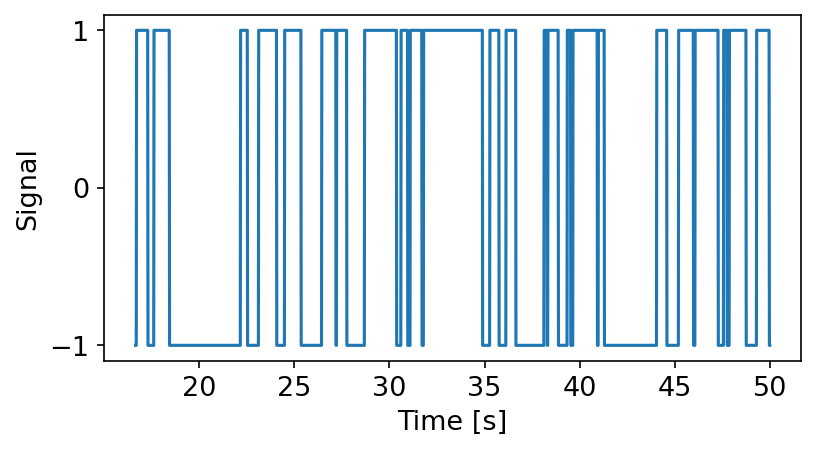

In [41]:
# Plot a section of the signal
index = 2
a = 1
interval = [1000, 3000]

signal = (signalArr[index].astype(np.float32) - 0.5) * 2 * a

plt.plot(tArr[index][interval[0]:interval[1]], signal[interval[0]:interval[1]])
plt.xlabel('Time [s]')
plt.ylabel('Signal')
plt.yticks([-a, 0, a])
plt.gcf().set_size_inches((6,3))
plt.show()

/tmp/ipykernel_65003/3683731188.py:17: RuntimeWarning: divide by zero encountered in divide
  plt.plot(fftBins, 400*1/fftBins, c='tab:orange', label='$f^{-1}$')
/tmp/ipykernel_65003/3683731188.py:18: RuntimeWarning: divide by zero encountered in divide
  plt.plot(fftBins, 500*1/fftBins**(0.5), c='black', label='$f^{-\\frac{1}{2}}$')


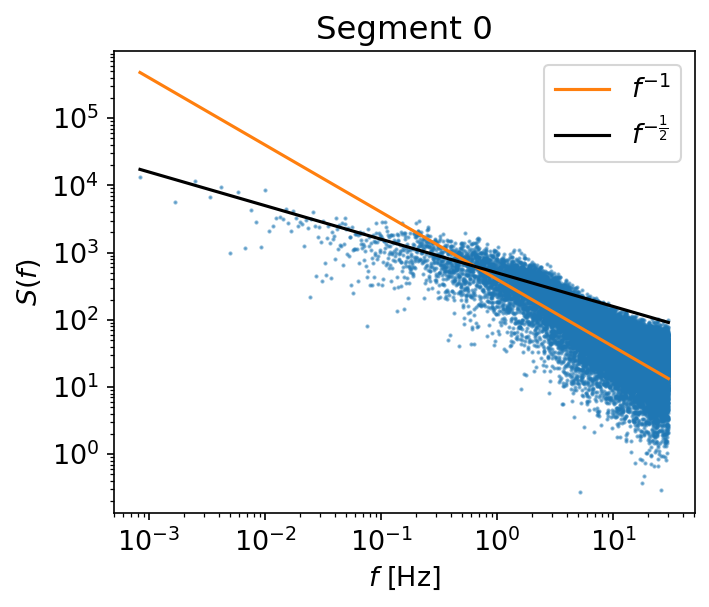

In [89]:
# Plot a section of the signal
index = 0
a = 1

signal = (signalArr[index].astype(np.float32) - 0.5) * 2 * a

fftBins = fftfreq(len(signal)) / dt
fftArr = fft(signal)
fftArr = np.abs(fftArr)

positiveIndex = np.where(fftBins >= 0)[0][-1]

fftBins = fftBins[:positiveIndex]
fftArr = fftArr[:positiveIndex]

plt.scatter(fftBins, fftArr, s=1, alpha=0.5)
plt.plot(fftBins, 400*1/fftBins, c='tab:orange', label='$f^{-1}$')
plt.plot(fftBins, 500*1/fftBins**(0.5), c='black', label='$f^{-\\frac{1}{2}}$')

plt.yscale('log') 
plt.xscale('log')
plt.ylabel('$S(f)$')
plt.xlabel('$f$ [Hz]')
plt.legend()
plt.gcf().set_size_inches((5,4))
plt.title(f'Segment {index}')
plt.show()

In [87]:
# Take the mean spectrum
a = 1

adjSignalArr = [(s.astype(np.float32) - 0.5) * 2 * a for s in signalArr]

n = int(np.max([len(s) for s in adjSignalArr]) / 2)
fftArr = np.array([np.abs(fft(s, n=n)) for s in adjSignalArr])
fftBins = fftfreq(n) / dt

positiveIndex = np.where(fftBins > 0)[0][-1]

fftBins = fftBins[:positiveIndex]
fftArr = fftArr[:,:positiveIndex]

# Normalize
#fftArr = (fftArr.T / np.max(fftArr, axis=-1)).T

meanFFTArr = np.mean(fftArr, axis=0)
stdFFTArr = np.std(fftArr, axis=0)

In [55]:
np.where(fftArr[-20] == 0)

(array([], dtype=int64),)

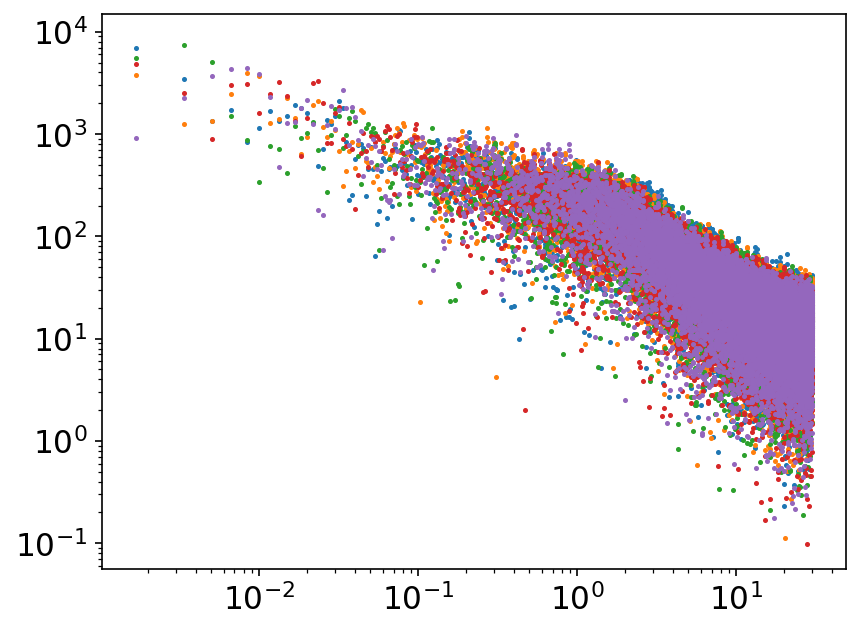

In [88]:
for i in range(100, 105):
    plt.scatter(fftBins, fftArr[i], s=2)

plt.yscale('log')
plt.xscale('log')
plt.show()

/tmp/ipykernel_34736/947329529.py:4: RuntimeWarning: divide by zero encountered in divide
  plt.plot(fftBins, 800*1/fftBins, c='tab:orange', label='$f^{-1}$')
/tmp/ipykernel_34736/947329529.py:5: RuntimeWarning: divide by zero encountered in divide
  plt.plot(fftBins, 600*1/fftBins**(0.5), c='black', label='$f^{-\\frac{1}{2}}$')


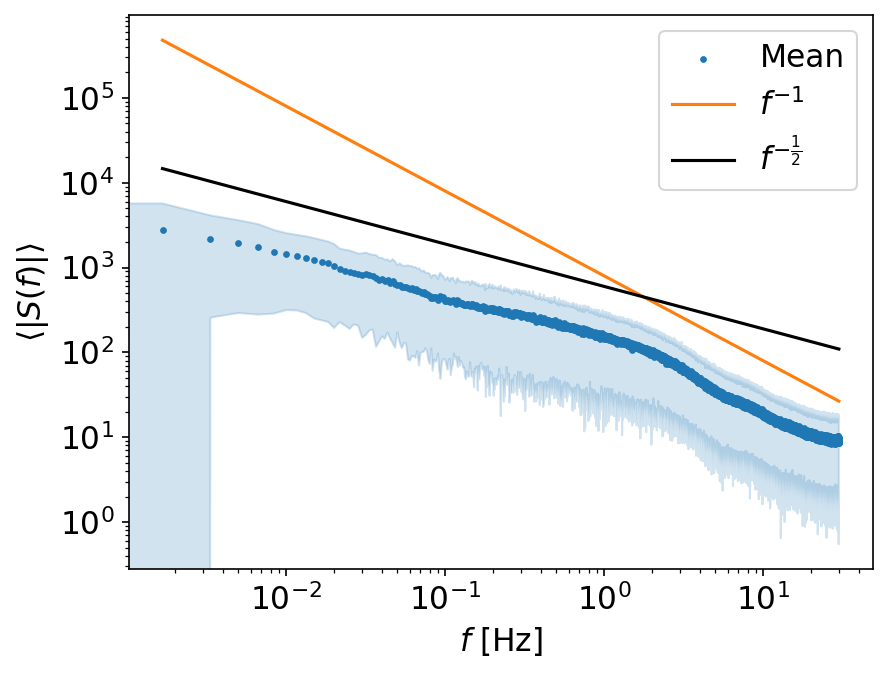

In [94]:
plt.scatter(fftBins, meanFFTArr, s=5, label='Mean')
plt.fill_between(fftBins, np.clip(meanFFTArr - stdFFTArr, 0, np.inf), meanFFTArr + stdFFTArr, color='tab:blue', alpha=0.2)

plt.plot(fftBins, 800*1/fftBins, c='tab:orange', label='$f^{-1}$')
plt.plot(fftBins, 600*1/fftBins**(0.5), c='black', label='$f^{-\\frac{1}{2}}$')

plt.yscale('log')
plt.xscale('log')
plt.ylabel('$\\langle | S(f) | \\rangle $')
plt.xlabel('$f$ [Hz]')
plt.legend()
plt.show()